# Clasificación de accidentes — Predicción Temporal v3

## Cambios respecto a v2
- **8 features por nodo**: grado, num_accidents, x, y, weight_mean, weight_max, weight_min, weight_std
- **Sin betweenness ni clustering**: más rápido de calcular, suficiente para tráfico
- **Modelo simplificado**: 2 capas TAGConv + BatchNorm + global_mean_pool + MLP
- Se mantienen: clip p1/p99, balanced accuracy, pesos de clase con sklearn


## 0. Instalación

In [ ]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.0 MB/s eta 0:00:00


## 1. Imports

In [ ]:
import os, pickle, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TAGConv, global_mean_pool
from torch_geometric.utils import add_self_loops
from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

print('Imports OK')

Imports OK


## 2. Configuración

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
CARPETA_GRAFOS = '/content/drive/MyDrive/AAGrafos/Proyecto/construccion_grafo/grafos_diferencia_sin_filtro_2'

EPOCHS     = 100
BATCH_SIZE = 32
LR         = 1e-4
HIDDEN     = 64
SEED       = 42
IN_CHANNELS = 8  # grado, num_accidents, x, y, w_mean, w_max, w_min, w_std

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


## 3. Enriquecimiento de features por nodo

Solo grado y estadísticas del weight (tiempo real - tiempo teórico).
Sin betweenness ni clustering — son costosos y poco informativos en redes viales regulares.


In [ ]:
def enriquecer_grafo(G):
    grados = dict(G.degree())

    for n in G.nodes():
        pesos = [G[n][nb].get('weight', 0.0) for nb in G.neighbors(n)]

        if pesos:
            pesos_np = np.array(pesos, dtype=np.float32)
            w_mean = float(np.mean(pesos_np))
            w_max  = float(np.max(pesos_np))
            w_min  = float(np.min(pesos_np))
            w_std  = float(np.std(pesos_np))
        else:
            w_mean = w_max = w_min = w_std = 0.0

        G.nodes[n]['grado']       = float(grados[n])
        G.nodes[n]['weight_mean'] = w_mean
        G.nodes[n]['weight_max']  = w_max
        G.nodes[n]['weight_min']  = w_min
        G.nodes[n]['weight_std']  = w_std

    return G

## 4. Conversión NetworkX → PyTorch Geometric

**8 features por nodo:** `[grado, num_accidents, x, y, weight_mean, weight_max, weight_min, weight_std]`


In [ ]:
def nx_to_pyg(G, label):
    node_list = list(G.nodes())
    node_idx  = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)

    src, dst, pesos = [], [], []
    for u, v, attr in G.edges(data=True):
        peso = abs(float(attr.get('weight', 1.0))) + 1e-6
        src  += [node_idx[u], node_idx[v]]
        dst  += [node_idx[v], node_idx[u]]
        pesos += [peso, peso]

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr  = torch.tensor(pesos, dtype=torch.float).unsqueeze(1)

    edge_index, edge_weight = add_self_loops(
        edge_index, edge_attr.squeeze(1), fill_value=1.0, num_nodes=num_nodes
    )
    edge_attr = edge_weight.unsqueeze(1)

    node_features = []
    for n in node_list:
        nd  = G.nodes[n]
        pos = nd.get('pos', (0.0, 0.0))
        node_features.append([
            nd.get('grado',        0.0),
            float(nd.get('num_accidents', 0)),
            float(pos[0]), float(pos[1]),
            nd.get('weight_mean',  0.0),
            nd.get('weight_max',   0.0),
            nd.get('weight_min',   0.0),
            nd.get('weight_std',   0.0),
        ])

    x = torch.tensor(node_features, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

## 5. Carga del dataset temporal

In [ ]:
def cargar_dataset_temporal(carpeta):
    archivos = sorted(glob.glob(os.path.join(carpeta, '*.pkl')))
    print(f'Archivos encontrados: {len(archivos)}')

    if len(archivos) < 2:
        raise ValueError('Se necesitan al menos 2 grafos.')

    grafos = []
    for i, path in enumerate(archivos):
        with open(path, 'rb') as f:
            G = pickle.load(f)
        G = enriquecer_grafo(G)
        grafos.append(G)
        if (i + 1) % 50 == 0:
            print(f'  Enriquecidos: {i+1}/{len(archivos)}')

    print('Todos los grafos enriquecidos.')

    dataset = []
    for i in range(len(grafos) - 1):
        G_t  = grafos[i]
        G_t1 = grafos[i + 1]
        label_t1 = int(any(
            G_t1.nodes[n].get('num_accidents', 0) > 0
            for n in G_t1.nodes()
        ))
        dataset.append(nx_to_pyg(G_t, label=label_t1))

    n_acc = sum(int(d.y.item()) for d in dataset)
    print(f'\nPares totales:        {len(dataset)}')
    print(f'Con accidente (t+1):  {n_acc} ({100*n_acc/len(dataset):.1f}%)')
    print(f'Sin accidente (t+1):  {len(dataset)-n_acc} ({100*(len(dataset)-n_acc)/len(dataset):.1f}%)')
    return dataset


dataset = cargar_dataset_temporal(CARPETA_GRAFOS)

Archivos encontrados: 720
  Enriquecidos: 50/720
  Enriquecidos: 100/720
  Enriquecidos: 150/720
  Enriquecidos: 200/720
  Enriquecidos: 250/720
  Enriquecidos: 300/720
  Enriquecidos: 350/720
  Enriquecidos: 400/720
  Enriquecidos: 450/720
  Enriquecidos: 500/720
  Enriquecidos: 550/720
  Enriquecidos: 600/720
  Enriquecidos: 650/720
  Enriquecidos: 700/720
Todos los grafos enriquecidos.

Pares totales:        719
Con accidente (t+1):  240 (33.4%)
Sin accidente (t+1):  479 (66.6%)


## 6. Split cronológico

In [ ]:
n = len(dataset)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

train_data = dataset[:train_end]
val_data   = dataset[train_end:val_end]
test_data  = dataset[val_end:]

print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')
print('\nDistribucion de labels:')
for nombre, split in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    n_pos = sum(int(d.y.item()) for d in split)
    print(f'  {nombre}: {n_pos}/{len(split)} con accidente ({100*n_pos/len(split):.1f}%)')

Train: 503 | Val: 108 | Test: 108

Distribucion de labels:
  Train: 169/503 con accidente (33.6%)
  Val: 30/108 con accidente (27.8%)
  Test: 41/108 con accidente (38.0%)


## 7. Clip de outliers + Estandarización

Los pesos van de -521 a 855 con mediana 1.0 — hay outliers extremos que dominarían el aprendizaje.
Todo se calcula solo sobre train para evitar data leakage.


In [ ]:
# 1. Percentiles p1/p99 sobre train
all_train_x = torch.cat([d.x for d in train_data], dim=0).numpy()
p1  = torch.tensor(np.percentile(all_train_x, 1,  axis=0), dtype=torch.float)
p99 = torch.tensor(np.percentile(all_train_x, 99, axis=0), dtype=torch.float)

print('Percentil  1:', p1.numpy().round(3))
print('Percentil 99:', p99.numpy().round(3))

# 2. Clip a los tres splits
for d in train_data + val_data + test_data:
    d.x = torch.clamp(d.x, min=p1, max=p99)

# 3. Media y std sobre train clippeado
all_train_clipped = torch.cat([d.x for d in train_data], dim=0)
mean_x = all_train_clipped.mean(dim=0)
std_x  = all_train_clipped.std(dim=0)
std_x[std_x == 0] = 1.0

# 4. Estandarizar
for d in train_data + val_data + test_data:
    d.x = (d.x - mean_x) / std_x

print('\nClip + estandarizacion aplicados.')

Percentil  1: [1. 0. 0. 0. 0. 0. 0. 0.]
Percentil 99: [2.000000e+01 0.000000e+00 5.874464e+05 6.155314e+06 9.883000e+00
 5.131700e+01 2.500000e+00 1.572100e+01]

Clip + estandarizacion aplicados.


## 8. DataLoaders

In [ ]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches en train: {len(train_loader)}')

Batches en train: 16


## 9. Modelo GNN

2 capas TAGConv + BatchNorm + global_mean_pool + MLP.

El `global_mean_pool` promedia los vectores de todos los nodos del grafo
en un único vector, que es el que entra al clasificador final.


In [ ]:
class AccidenteGNN(nn.Module):
    def __init__(self, in_channels, hidden=64, K=2):
        super().__init__()
        self.conv1 = TAGConv(in_channels, hidden, K=K)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.conv2 = TAGConv(hidden, hidden, K=K)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.mlp = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(hidden // 2, 2),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        w = edge_attr.squeeze(1)
        x = F.relu(self.bn1(self.conv1(x, edge_index, w)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, w)))
        x = global_mean_pool(x, batch)
        return self.mlp(x)

## 10. Funciones de entrenamiento y evaluación

In [ ]:
def entrenar(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluar(model, loader, device):
    model.eval()
    preds, labels = [], []
    for batch in loader:
        batch = batch.to(device)
        pred  = model(batch).argmax(dim=1)
        preds.append(pred.cpu())
        labels.append(batch.y.cpu())
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()

    acc     = accuracy_score(labels, preds)
    bal_acc = balanced_accuracy_score(labels, preds)
    f1      = f1_score(labels, preds, zero_division=0)
    return acc, bal_acc, f1, torch.tensor(preds), torch.tensor(labels)

## 11. Entrenamiento

El mejor modelo se guarda por **balanced accuracy** en validación,
no accuracy simple, para evitar que colapse a predecir siempre la clase mayoritaria.


In [ ]:
model     = AccidenteGNN(in_channels=IN_CHANNELS, hidden=HIDDEN).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10
)

# Pesos de clase para manejar desbalance
labels_train_np = np.array([int(d.y.item()) for d in train_data])
class_weights   = compute_class_weight('balanced', classes=np.array([0, 1]), y=labels_train_np)
weights         = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion       = nn.CrossEntropyLoss(weight=weights)
print(f'Pesos -> sin accidente: {weights[0]:.3f} | con accidente: {weights[1]:.3f}\n')

history = {'train_loss': [], 'val_acc': [], 'val_bal_acc': [], 'val_f1': []}
best_bal_acc     = 0.0
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    loss = entrenar(model, train_loader, optimizer, criterion, device)
    val_acc, val_bal, val_f1, _, _ = evaluar(model, val_loader, device)

    history['train_loss'].append(loss)
    history['val_acc'].append(val_acc)
    history['val_bal_acc'].append(val_bal)
    history['val_f1'].append(val_f1)

    scheduler.step(val_bal)
    lr = optimizer.param_groups[0]['lr']

    if val_bal > best_bal_acc:
        best_bal_acc     = val_bal
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f'Ep {epoch:3d} | Loss: {loss:.4f} | Acc: {val_acc:.4f} | '
              f'Bal Acc: {val_bal:.4f} | F1: {val_f1:.4f} | LR: {lr:.6f}')

print(f'\nMejor Val Balanced Acc: {best_bal_acc:.4f}')

Pesos -> sin accidente: 0.753 | con accidente: 1.488

Ep   1 | Loss: 0.6939 | Acc: 0.7222 | Bal Acc: 0.5000 | F1: 0.0000 | LR: 0.000100
Ep  10 | Loss: 0.6765 | Acc: 0.6667 | Bal Acc: 0.5744 | F1: 0.3793 | LR: 0.000100
Ep  20 | Loss: 0.6591 | Acc: 0.6574 | Bal Acc: 0.5885 | F1: 0.4127 | LR: 0.000050
Ep  30 | Loss: 0.6627 | Acc: 0.6481 | Bal Acc: 0.5923 | F1: 0.4242 | LR: 0.000050
Ep  40 | Loss: 0.6569 | Acc: 0.6389 | Bal Acc: 0.5859 | F1: 0.4179 | LR: 0.000025
Ep  50 | Loss: 0.6491 | Acc: 0.6389 | Bal Acc: 0.5859 | F1: 0.4179 | LR: 0.000025
Ep  60 | Loss: 0.6524 | Acc: 0.6481 | Bal Acc: 0.6026 | F1: 0.4412 | LR: 0.000013
Ep  70 | Loss: 0.6497 | Acc: 0.6389 | Bal Acc: 0.5859 | F1: 0.4179 | LR: 0.000006
Ep  80 | Loss: 0.6563 | Acc: 0.6481 | Bal Acc: 0.6026 | F1: 0.4412 | LR: 0.000003
Ep  90 | Loss: 0.6495 | Acc: 0.6481 | Bal Acc: 0.6026 | F1: 0.4412 | LR: 0.000002
Ep 100 | Loss: 0.6497 | Acc: 0.6481 | Bal Acc: 0.6026 | F1: 0.4412 | LR: 0.000002

Mejor Val Balanced Acc: 0.6026


## 12. Evaluación final en test

In [ ]:
model.load_state_dict(best_model_state)
test_acc, test_bal, test_f1, preds, labels = evaluar(model, test_loader, device)

print('=' * 60)
print(f'Test Accuracy:          {test_acc:.4f}')
print(f'Test Balanced Accuracy: {test_bal:.4f}  <- metrica principal')
print(f'Test F1 (clase pos):    {test_f1:.4f}')
print('\nReporte de clasificacion:')
print(classification_report(labels, preds,
                              target_names=['Sin accidente', 'Con accidente'],
                              zero_division=0))
print('Matriz de confusion:')
print(confusion_matrix(labels, preds))

Test Accuracy:          0.7222
Test Balanced Accuracy: 0.7525  <- metrica principal
Test F1 (clase pos):    0.7059

Reporte de clasificacion:
               precision    recall  f1-score   support

Sin accidente       0.89      0.63      0.74        67
Con accidente       0.59      0.88      0.71        41

     accuracy                           0.72       108
    macro avg       0.74      0.75      0.72       108
 weighted avg       0.78      0.72      0.73       108

Matriz de confusion:
[[42 25]
 [ 5 36]]


## 13. Comparación con baselines

Usamos **balanced accuracy** para comparar — la accuracy simple engaña con clases desbalanceadas.


In [ ]:
prop_pos      = labels_train_np.mean()
clase_mayoria = int(prop_pos >= 0.5)

np.random.seed(SEED)
preds_majority = torch.full_like(labels, clase_mayoria)
preds_random   = torch.tensor(np.random.randint(0, 2, size=len(labels)))
preds_prop     = torch.tensor(
    np.random.choice([0, 1], size=len(labels), p=[1-prop_pos, prop_pos])
)

resultados = [
    ('Clase mayoritaria', preds_majority),
    ('Aleatorio 50/50',   preds_random),
    ('Aleatorio prop.',   preds_prop),
    ('GNN (tu modelo)',   preds),
]

print(f'{"Modelo":<25} {"Accuracy":>10} {"Bal. Acc":>10} {"F1":>8}')
print('-' * 58)
for nombre, p in resultados:
    acc = accuracy_score(labels.numpy(), p.numpy())
    bal = balanced_accuracy_score(labels.numpy(), p.numpy())
    f1  = f1_score(labels.numpy(), p.numpy(), zero_division=0)
    print(f'{nombre:<25} {acc:>10.4f} {bal:>10.4f} {f1:>8.4f}')

Modelo                      Accuracy   Bal. Acc       F1
----------------------------------------------------------
Clase mayoritaria             0.6204     0.5000   0.0000
Aleatorio 50/50               0.5000     0.5213   0.4808
Aleatorio prop.               0.5000     0.4550   0.2895
GNN (tu modelo)               0.7222     0.7525   0.7059


## 14. Curvas de entrenamiento

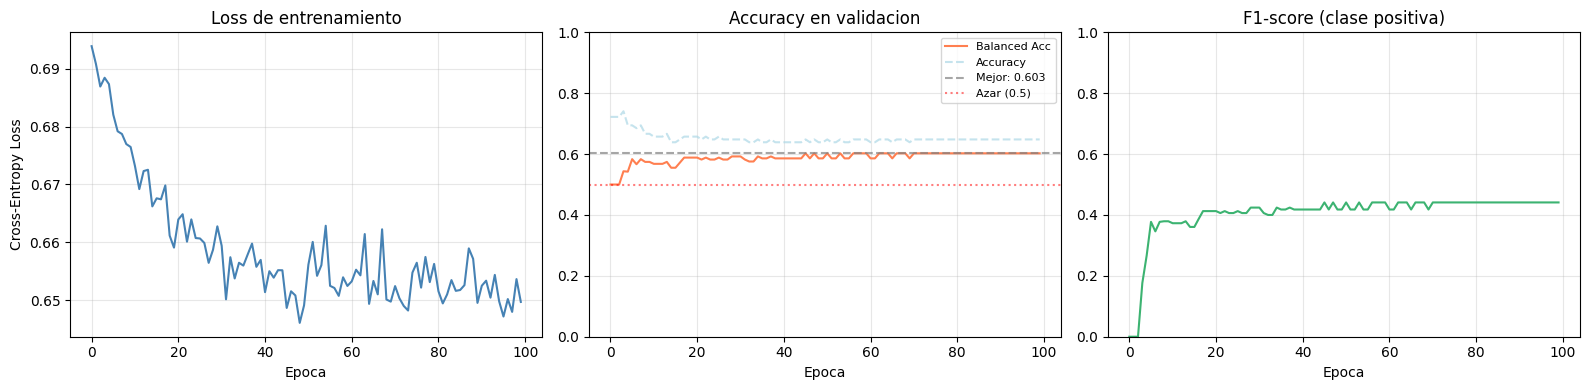

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_title('Loss de entrenamiento')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_bal_acc'], color='coral', label='Balanced Acc')
axes[1].plot(history['val_acc'], color='lightblue', linestyle='--', label='Accuracy', alpha=0.7)
axes[1].axhline(y=best_bal_acc, color='gray', linestyle='--', alpha=0.7,
                label=f'Mejor: {best_bal_acc:.3f}')
axes[1].axhline(y=0.5, color='red', linestyle=':', alpha=0.5, label='Azar (0.5)')
axes[1].set_title('Accuracy en validacion')
axes[1].set_xlabel('Epoca')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_f1'], color='mediumseagreen')
axes[2].set_title('F1-score (clase positiva)')
axes[2].set_xlabel('Epoca')
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento_v3.png', dpi=150)
plt.show()

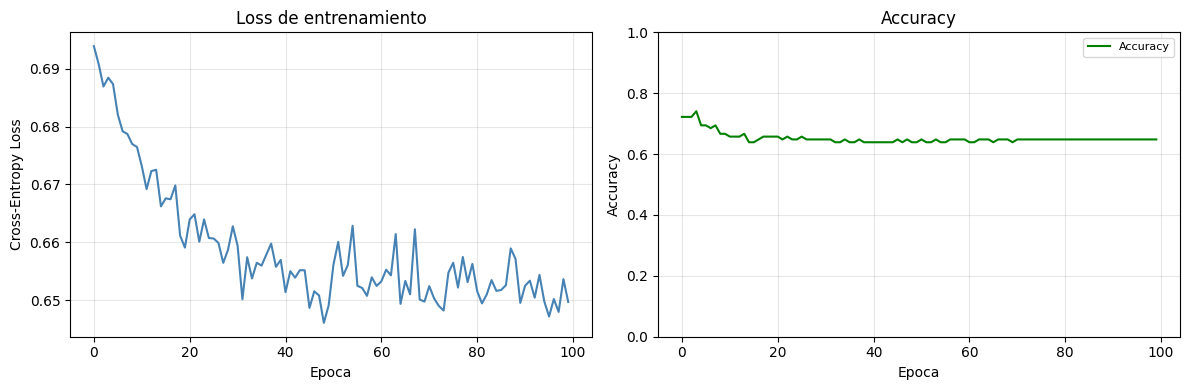

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_title('Loss de entrenamiento')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_acc'], color='green', label='Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

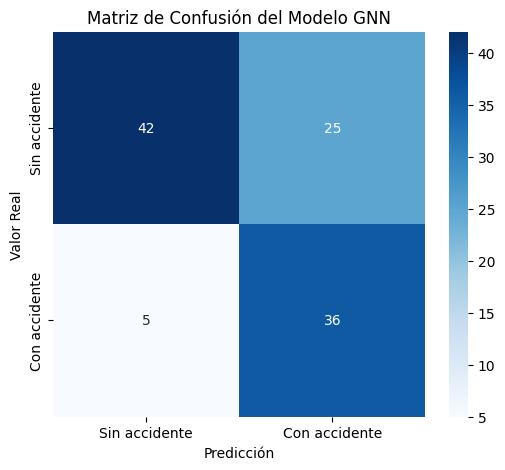

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin accidente', 'Con accidente'],
            yticklabels=['Sin accidente', 'Con accidente'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión del Modelo GNN')
plt.savefig('/content/drive/MyDrive/AAGrafos/Proyecto/matriz_confusion_gnn_temp.png', dpi=150)
plt.show()

## 15. Predicción para nuevos grafos

Aplica el mismo pipeline: enriquecimiento → clip → estandarización.


In [ ]:
def predecir_accidente_siguiente_hora(G_t, model, p1, p99, mean_x, std_x, device):
    G_t  = enriquecer_grafo(G_t)
    data = nx_to_pyg(G_t, label=0)
    data.x = torch.clamp(data.x, min=p1, max=p99)
    data.x = (data.x - mean_x) / std_x
    data   = data.to(device)

    model.eval()
    with torch.no_grad():
        out            = model(data)
        probs          = F.softmax(out, dim=1)
        pred_clase     = probs.argmax(dim=1).item()
        prob_accidente = probs[0, 1].item()

    return pred_clase, prob_accidente


# Ejemplo con un grafo del test set
import random
archivos_todos = sorted(glob.glob(os.path.join(CARPETA_GRAFOS, '*.pkl')))
n_total        = len(archivos_todos)
test_start_idx = int((n_total - 1) * (TRAIN_RATIO + VAL_RATIO))

idx     = random.randint(test_start_idx, n_total - 2)
path_t  = archivos_todos[idx]
path_t1 = archivos_todos[idx + 1]

with open(path_t,  'rb') as f: G_t  = pickle.load(f)
with open(path_t1, 'rb') as f: G_t1 = pickle.load(f)

label_real = int(any(G_t1.nodes[n].get('num_accidents', 0) > 0 for n in G_t1.nodes()))
pred_clase, prob_accidente = predecir_accidente_siguiente_hora(
    G_t, model, p1, p99, mean_x, std_x, device
)

print(f'Grafo t:     {os.path.basename(path_t)}')
print(f'Grafo t+1:   {os.path.basename(path_t1)}')
print(f'Prediccion:  {"Con accidente" if pred_clase == 1 else "Sin accidente"}')
print(f'Prob acc:    {prob_accidente:.4f}')
print(f'Label real:  {"Con accidente" if label_real == 1 else "Sin accidente"}')
print(f'Resultado:   {"Correcta" if pred_clase == label_real else "Incorrecta"}')

Grafo t:     grafo_2022_09_28_02.pkl
Grafo t+1:   grafo_2022_09_28_03.pkl
Prediccion:  Sin accidente
Prob acc:    0.3585
Label real:  Sin accidente
Resultado:   Correcta


In [ ]:
# ===========================================================================
# BASELINE: Clasificador de clase mayoritaria (dummy classifier)
# ===========================================================================
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Extraer labels del conjunto de train y test
y_train = [int(d.y.item()) for d in train_data]
y_test = [int(d.y.item()) for d in test_data]

# Entrenar el baseline (predice siempre la clase más frecuente en train)
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit([[0]] * len(y_train), y_train) # X dummy, solo importan los labels
y_pred_baseline = dummy.predict([[0]] * len(y_test))

# Evaluación
clase_mayoritaria = dummy.classes_[dummy.class_prior_.argmax()]
print(f"Clase mayoritaria en train: {'Con accidente' if clase_mayoritaria == 1 else 'Sin accidente'} (clase {clase_mayoritaria})")
print(f"\nBaseline Accuracy: {(y_pred_baseline == y_test).mean():.4f}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_baseline,
target_names=["Sin accidente", "Con accidente"]))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_baseline))

Clase mayoritaria en train: Sin accidente (clase 0)

Baseline Accuracy: 0.6204

Reporte de clasificación:
               precision    recall  f1-score   support

Sin accidente       0.62      1.00      0.77        67
Con accidente       0.00      0.00      0.00        41

     accuracy                           0.62       108
    macro avg       0.31      0.50      0.38       108
 weighted avg       0.38      0.62      0.48       108

Matriz de confusión:
[[67  0]
 [41  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
